# zhou2023 — Zhou et al. (2023) Comparing Mapper Graphs Across Layers

One **L2-norm Mapper graph per layer**, compared with the **Gromov–Wasserstein** distance — the paper's central tool.


## What the paper does

Builds a **Mapper** graph of the activations at *each* layer (the same `L2`-norm lens as TopoAct) and **compares** the per-layer graphs with a **Gromov–Wasserstein (GW)** distance. Each Mapper graph is treated as a **hypergraph**: a node is the *set of samples* it contains (a hyperedge), and the distance between two nodes is the **Jaccard distance** between those sets, `w(v, v') = 1 - |y ∩ y'| / |y ∪ y'|` (paper, §4). Node masses are proportional to cluster size.  GW gives one number for how much the activation topology differs between two layers.

**Methodology:** per-layer activations → per-layer Mapper graph → pairwise GW distance.

**Expected result:** GW quantifies how the activation topology reshapes across the network, broadly shrinking toward the class-separated late layers.


## Dataset & model in the paper

- **Venue:** TopoInVis 2023 (co-located with IEEE VIS)
- **Datasets used:** CIFAR-10 activations.
- **Models used:** Standard CNN classifiers; activations across layers.
- **Headline result to aim for:** GW distance between layer-wise Mapper graphs quantifies how activation topology changes with depth.
- **Reference code:** [https://github.com/tdavislab/mapper-compare](https://github.com/tdavislab/mapper-compare)

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook runs on real activations.**  A small CNN is trained on the local CIFAR-10 cache; we Mapper *each* layer and compare with GW.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, accuracy, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Train a CNN, take per-layer activations


In [2]:
X_tr, y_tr = load_cifar10('train', n_samples=2000)
X_te, y_te = load_cifar10('test',  n_samples=400)
model = CNN_FCN(in_channels=3, num_classes=10, width=16, feat=64, hidden=32)
train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=6,
              aspects=['activations'], device=DEVICE, verbose=False)
snap = extract_snapshot(model.to('cpu').eval(), X_te[:300],
                        aspects=['activations'], layer_selection='linear_and_conv')
layers = [a.reshape(a.shape[0], -1) for a in snap.all_activation_matrices()]
print('per-layer activation shapes:', [a.shape for a in layers])


paper_reproduce/_torch_setup.py:525: UserWarning: Model 'Sequential' has both fully-connected (linear / SoRO) and conv layers. Defaulting to the fully-connected layers. Pass layer_selection='all_linear', 'all_conv', 'soro', 'linear_and_conv', 'all', or a list of names/indices to suppress this warning.
  extractor = TrainingExtractor(


per-layer activation shapes: [(300, 16384), (300, 16384), (300, 32), (300, 10)]


## 2. One Mapper graph per layer

We fit the preset to **each layer separately** — feeding the whole list at once would concatenate the layers into a single graph, leaving nothing to compare.


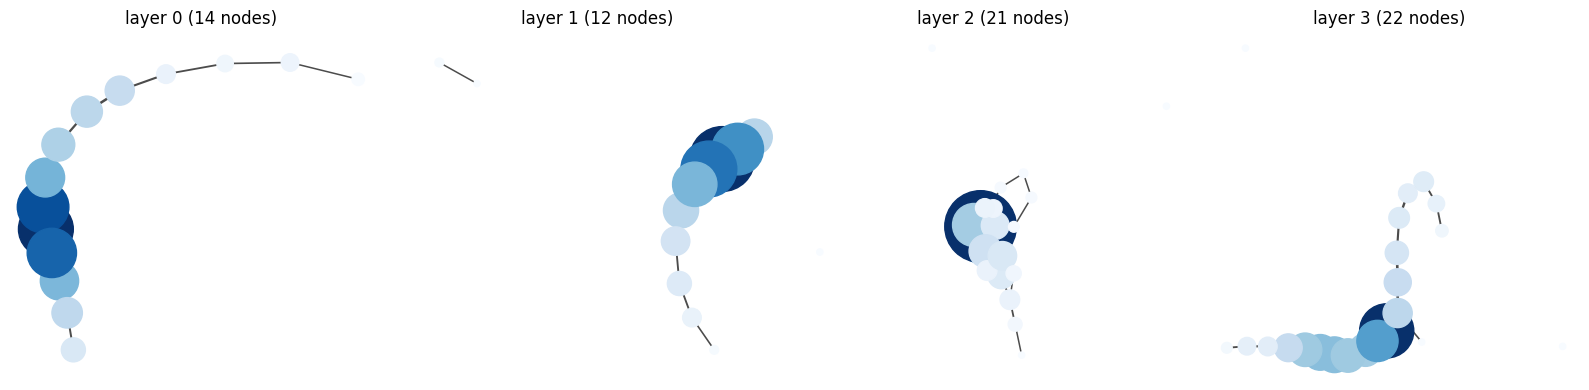

In [3]:
pipe = TDAPipeline.from_paper("zhou2023",
                            tool_kwargs__n_intervals=14,
                            tool_kwargs__overlap_frac=0.3)
results = [pipe.fit(layer) for layer in layers]   # one Mapper graph per layer
import networkx as nx
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4))
for ax, (i, r) in zip(np.atleast_1d(axes), enumerate(results)):
    r.plot('graph', title=f'layer {i} ({r.mapper.graph.number_of_nodes()} nodes)', ax=ax)
plt.tight_layout(); plt.show()


## 3. Gromov–Wasserstein distances between the layers' Mapper graphs

The paper's construction, via `mapper_hypernetwork_gw_distance`: each Mapper graph becomes a hypernetwork `(X, mu, Y, nu, omega)`, and two of them are compared by **co-optimal transport** over a sample coupling and a node coupling at once (their Eq. 3). Requires POT.


.../site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


consecutive-layer GW: ['L0->L1: 2.421', 'L1->L2: 2.004', 'L2->L3: 3.562']


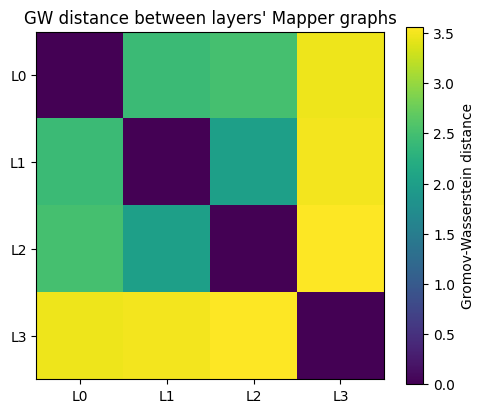

In [4]:
from tanc.topo_tools import mapper_hypernetwork_gw_distance
L = len(results)
GW = np.zeros((L, L))
for i in range(L):
    for j in range(i + 1, L):
        # Pass the TopoResults: omega is built from node->sample memberships.
        # COOT is non-convex, so this is an upper bound; more restarts tighten it.
        GW[i, j] = GW[j, i] = mapper_hypernetwork_gw_distance(
            results[i], results[j], n_restarts=20)
print('consecutive-layer GW:',
      [f'L{i}->L{i+1}: {GW[i, i+1]:.3f}' for i in range(L - 1)])

plt.figure(figsize=(5, 4.2))
plt.imshow(GW, cmap='viridis')
plt.colorbar(label='Gromov-Wasserstein distance')
plt.xticks(range(L), [f'L{i}' for i in range(L)])
plt.yticks(range(L), [f'L{i}' for i in range(L)])
plt.title("GW distance between layers' Mapper graphs")
plt.tight_layout(); plt.show()


## Notes & gaps

* Implements the paper's construction on real CIFAR-10 activations: one Mapper graph per layer, each read as a hypernetwork, compared by **co-optimal transport** (their Eq. 3) via `mapper_hypernetwork_gw_distance`. `omega` is the shortest-path Jaccard distance on the line graph (Eq. 2) and the measures are degree-based, matching the authors' reference code at [tdavislab/mapper-compare](https://github.com/tdavislab/mapper-compare).
* **The values are upper bounds.** COOT is non-convex and solved by block-coordinate descent, so each number is the best of `n_restarts` local optima. The paper's text uses 20 random instances; the authors' code uses one uniform start. Raise `n_restarts` for a tighter bound.
* The exact 'monotonic decrease with depth' is scale-dependent (small per-layer graphs are noisy and sometimes disconnected); train wider / use more samples and the paper's `Mapper(40, 0.2)` cover to sharpen it.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| solver | co-optimal transport, Eq. 3 | the same, via POT's `co_optimal_transport2` | matches the authors' reference code; but COOT is non-convex, so each value is an **upper bound** from `n_restarts` local optima |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
